# Liver Stiffness Measurement (LSM) Analysis
## NHANES 2017–18, 2017–2020, and 2021–22

**Prerequisite:** Run `01_download_nhanes_lsm.ipynb` first to populate `../data/derived/`.

Three NHANES cycles with FibroScan (VCTE) data:

| Cycle | Parquet | Notes |
|-------|---------|-------|
| 2017–18 | `2017_2018.parquet` | From `nhanes_mortality_fibrosis/01_data_download.ipynb` |
| 2017–2020 pre-pandemic | `2017_2020_prepandemic.parquet` | Supersedes 2017-18; includes Jan 2019–Mar 2020 data |
| 2021–22 | `2021_2022.parquet` | Most recent cycle with LSM |

**LSM thresholds (Castera/EASL):**

| Category | kPa | Histologic stage |
|----------|-----|------------------|
| Low | < 7.1 | F0–F1 (none–mild) |
| Intermediate | 7.1–9.4 | F2 (significant) |
| High | ≥ 9.5 | F3–F4 (severe–cirrhosis) |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

DERIVED = os.path.abspath(os.path.join('..', 'data', 'derived'))

LSM_F01   = 7.1   # F0-F1 upper boundary
LSM_F34   = 9.5   # F3-F4 lower boundary
FIB4_LOW  = 1.30
FIB4_HIGH = 2.67

AGE_BINS   = [17, 29, 39, 49, 59, 69, 120]
AGE_LABELS = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']

print('Setup complete')

Setup complete


## 1. Load parquet files

In [2]:
def load_lsm_parquet(stem, cycle_label=None):
    """Load a derived parquet and add derived columns for LSM analysis."""
    path = os.path.join(DERIVED, f'{stem}.parquet')
    df = pd.read_parquet(path)
    if cycle_label:
        df['CYCLE'] = cycle_label

    # FIB-4 (recalculate if components present; age threshold ≥ 35)
    mask = (df['AST'] > 0) & (df['ALT'] > 0) & (df['PLATELETS'] > 0) & (df['AGE'] >= 35)
    df['FIB4'] = np.nan
    df.loc[mask, 'FIB4'] = (
        df.loc[mask, 'AGE'] * df.loc[mask, 'AST'] /
        (df.loc[mask, 'PLATELETS'] * np.sqrt(df.loc[mask, 'ALT']))
    )

    # LSM reliability flag
    if 'LSM_IQR_RATIO' not in df.columns and 'LSM_IQR' in df.columns:
        df['LSM_IQR_RATIO'] = df['LSM_IQR'] / df['LSM_KPA']
    elif 'LSM_IQR_RATIO' not in df.columns:
        df['LSM_IQR_RATIO'] = np.nan

    # LSM category
    df['LSM_CAT'] = pd.cut(
        df['LSM_KPA'],
        bins=[0, LSM_F01, LSM_F34, np.inf],
        labels=['Low F0-F1 (<7.1)', 'Intermediate (7.1-9.4)', 'High F3-F4 (≥9.5)']
    )

    # Ensure SEX and RACE labels
    if 'SEX' not in df.columns:
        df['SEX'] = df['FEMALE'].map({0: 'Male', 1: 'Female'})
    if 'RACE' not in df.columns:
        RACE_MAP = {1: 'Mexican American', 2: 'Other Hispanic',
                    3: 'Non-Hispanic White', 4: 'Non-Hispanic Black', 5: 'Other/Multi-Racial'}
        df['RACE'] = df['RIDRETH1'].map(RACE_MAP)

    df['AGE_GROUP'] = pd.cut(df['AGE'], bins=AGE_BINS, labels=AGE_LABELS)

    n     = len(df)
    lsm_n = df['LSM_KPA'].notna().sum()
    print(f"{df['CYCLE'].iloc[0]}: {n:,} adults | LSM: {lsm_n:,} ({lsm_n/n*100:.0f}%)")
    return df


df_j = load_lsm_parquet('2017_2018')
df_p = load_lsm_parquet('2017_2020_prepandemic')
df_l = load_lsm_parquet('2021_2022')

COMMON = ['SEQN', 'AGE', 'AGE_GROUP', 'SEX', 'FEMALE', 'RACE',
          'BMXBMI', 'CYCLE', 'AST', 'ALT', 'PLATELETS', 'FIB4',
          'LSM_KPA', 'CAP_DBM', 'LSM_IQR_RATIO', 'LSM_CAT']

def align(df):
    for col in COMMON:
        if col not in df.columns:
            df[col] = np.nan
    return df[COMMON]

# Cross-sectional pool: use 2017-2020 (supersedes 2017-18) + 2021-22
df_cross = pd.concat([align(df_p), align(df_l)], ignore_index=True)

# Pseudo-cohort pool: 2017-2020 and 2021-22 (two distinct time windows)
df_pseudo = df_cross.copy()

print(f'\nCross-sectional pool (2017-2020 + 2021-22): {len(df_cross):,} adults')

2017-2018: 5,809 adults | LSM: 5,091 (88%)
2017-2020: 8,965 adults | LSM: 8,318 (93%)
2021-2022: 6,337 adults | LSM: 5,874 (93%)

Cross-sectional pool (2017-2020 + 2021-22): 15,302 adults


## 2. Valid LSM readings

Restrict to LSM values with IQR/median ≤ 0.30 (EASL reliability criterion).
The 2017-18 cycle lacks the IQR column in our parquet; for that cycle all readings are kept.

In [3]:
def valid_lsm(df):
    return df[
        df['LSM_KPA'].notna() &
        (df['LSM_KPA'] > 0) &
        (df['LSM_IQR_RATIO'].isna() | (df['LSM_IQR_RATIO'] <= 0.30))
    ].copy()

lsm_cross  = valid_lsm(df_cross)
lsm_pseudo = valid_lsm(df_pseudo)

print('Valid LSM readings by cycle:')
for cyc, sub in lsm_cross.groupby('CYCLE'):
    print(f'  {cyc}: {len(sub):,}')
print(f'  Total: {len(lsm_cross):,}')

Valid LSM readings by cycle:
  2017-2020: 8,104
  2021-2022: 5,687
  Total: 13,791


## 3. Cross-sectional LSM by age, sex, and race

In [4]:
print('Median LSM (kPa) by age group and sex (2017-2020 + 2021-22):')
tbl = lsm_cross.groupby(['AGE_GROUP', 'SEX'])['LSM_KPA'].agg(
    n='count', median='median', mean='mean',
    Q25=lambda x: x.quantile(0.25), Q75=lambda x: x.quantile(0.75)
).round(2)
display(tbl)

Median LSM (kPa) by age group and sex (2017-2020 + 2021-22):


n  median  mean  Q25  Q75
AGE_GROUP SEX                                 
18-29     Female  1191     4.5  4.84  3.7  5.3
          Male    1218     5.0  5.53  4.2  6.0
30-39     Female  1086     4.5  5.18  3.7  5.6
          Male     939     5.1  5.80  4.3  6.1
40-49     Female  1037     4.6  5.30  3.9  5.8
          Male     937     5.1  6.24  4.3  6.3
50-59     Female  1184     5.1  6.21  4.1  6.5
          Male    1013     5.4  6.93  4.5  6.8
60-69     Female  1481     5.0  5.92  4.0  6.3
          Male    1365     5.4  7.15  4.4  6.9
70+       Female  1189     5.0  5.81  4.1  6.2
          Male    1151     5.5  6.88  4.3  6.8

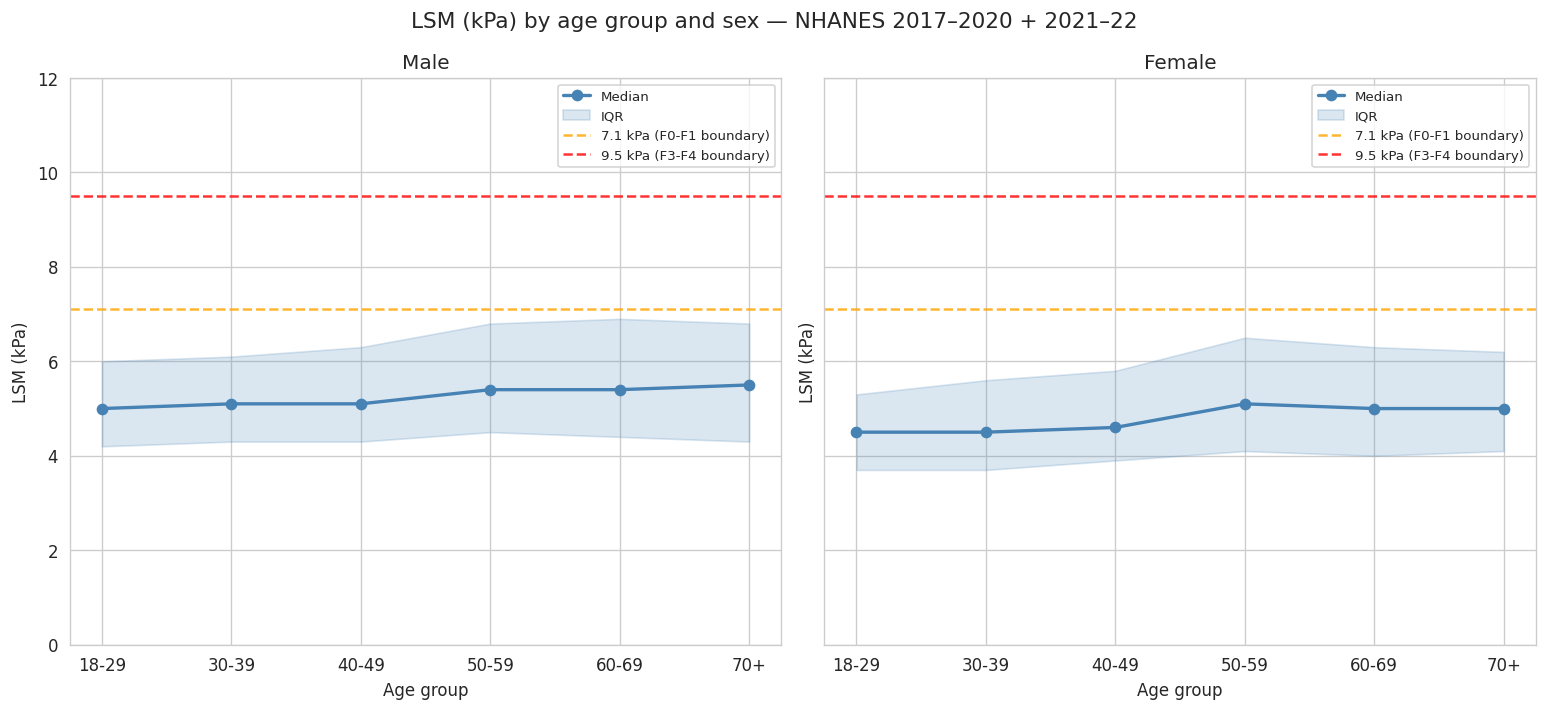

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, sex in zip(axes, ['Male', 'Female']):
    sub = lsm_cross[lsm_cross['SEX'] == sex].groupby('AGE_GROUP')['LSM_KPA'].agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    ).reindex(AGE_LABELS)
    xs = range(len(sub))
    ax.plot(xs, sub['median'], 'o-', color='steelblue', lw=2, label='Median')
    ax.fill_between(xs, sub['q25'], sub['q75'], alpha=0.2, color='steelblue', label='IQR')
    ax.axhline(LSM_F01, color='orange', ls='--', alpha=0.8, label=f'{LSM_F01} kPa (F0-F1 boundary)')
    ax.axhline(LSM_F34, color='red',    ls='--', alpha=0.8, label=f'{LSM_F34} kPa (F3-F4 boundary)')
    ax.set_xticks(xs); ax.set_xticklabels(AGE_LABELS)
    ax.set_xlabel('Age group'); ax.set_ylabel('LSM (kPa)')
    ax.set_title(f'{sex}')
    ax.legend(fontsize=8); ax.set_ylim(0, 12)

plt.suptitle('LSM (kPa) by age group and sex — NHANES 2017–2020 + 2021–22', fontsize=13)
plt.tight_layout()
plt.show()

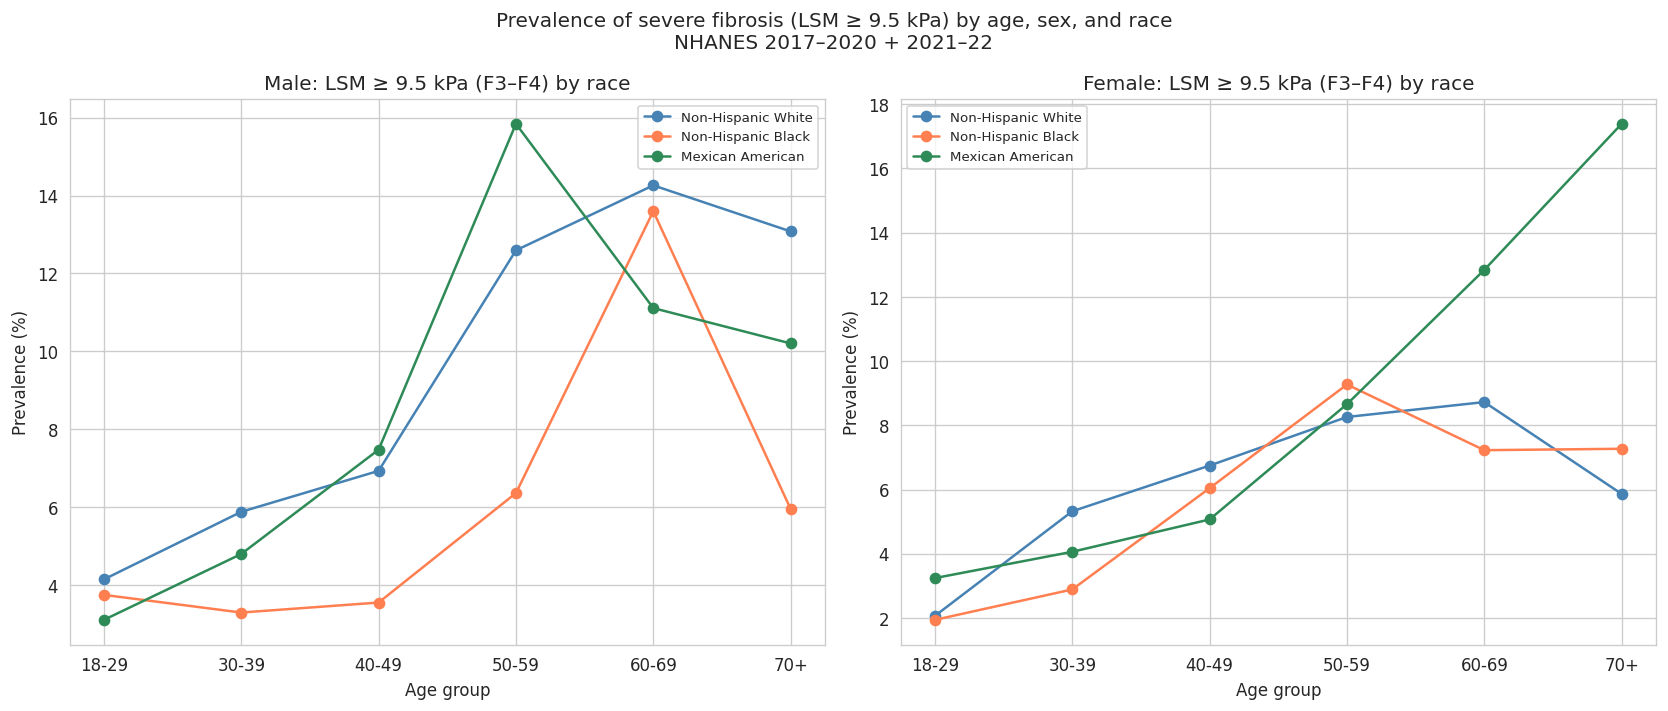

In [6]:
# Prevalence of F3-F4 (LSM ≥ 9.5 kPa) by age, sex, and race
main_races = ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American']
colors     = {'Non-Hispanic White': 'steelblue', 'Non-Hispanic Black': 'coral',
              'Mexican American': 'seagreen'}

prev_race = lsm_cross.groupby(['AGE_GROUP', 'SEX', 'RACE']).apply(
    lambda g: pd.Series({
        'n':       len(g),
        'pct_F34': (g['LSM_KPA'] >= LSM_F34).mean() * 100,
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, sex in zip(axes, ['Male', 'Female']):
    for race in main_races:
        sub = (prev_race[(prev_race['SEX'] == sex) &
                         (prev_race['RACE'] == race) &
                         (prev_race['n'] >= 20)]
               .set_index('AGE_GROUP').reindex(AGE_LABELS).reset_index())
        ax.plot(range(len(sub)), sub['pct_F34'], 'o-', color=colors[race], label=race)
    ax.set_xticks(range(len(AGE_LABELS))); ax.set_xticklabels(AGE_LABELS)
    ax.set_xlabel('Age group'); ax.set_ylabel('Prevalence (%)')
    ax.set_title(f'{sex}: LSM ≥ 9.5 kPa (F3–F4) by race')
    ax.legend(fontsize=8)

plt.suptitle('Prevalence of severe fibrosis (LSM ≥ 9.5 kPa) by age, sex, and race\n'
             'NHANES 2017–2020 + 2021–22', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Pseudo-cohort: birth cohort trajectories across two time windows

Using 2017-2020 (midpoint ≈ 2018.5) and 2021-22 (midpoint ≈ 2022), each birth cohort
is measured at two points roughly 3.5 years apart. The delta in median LSM estimates
the population-level annual LSM change for that cohort.

Limitations:
- Only 2 time points → noisy estimates; cannot distinguish secular trend from aging
- Survivor bias: those with rapidly progressive fibrosis may die between measurements
- The 2017-2020 pre-pandemic and 2021-22 cycles may differ in exam conditions (COVID era)

In [7]:
# Pre-pandemic cycle midpoint: data collected Jan 2017 – Mar 2020, midpoint ≈ Aug 2018
# 2021-22 midpoint: Jan 2021 – Dec 2022, midpoint ≈ Jul 2022
CYCLE_MID = {'2017-2020': 2018.5, '2021-2022': 2022.0}

lsm_pseudo['CYCLE_MID']    = lsm_pseudo['CYCLE'].map(CYCLE_MID)
lsm_pseudo['BIRTH_YEAR']   = lsm_pseudo['CYCLE_MID'] - lsm_pseudo['AGE']
lsm_pseudo['BIRTH_COHORT'] = (lsm_pseudo['BIRTH_YEAR'] // 5) * 5

cohort_lsm = lsm_pseudo.groupby(['BIRTH_COHORT', 'CYCLE', 'SEX']).agg(
    lsm_median=('LSM_KPA', 'median'),
    lsm_mean=  ('LSM_KPA', 'mean'),
    age_median=('AGE',     'median'),
    n=         ('LSM_KPA', 'count'),
).reset_index()

# Keep cells with ≥ 30 readings and cohorts present in both cycles
cohort_lsm = cohort_lsm[cohort_lsm['n'] >= 30]
both = (cohort_lsm.groupby(['BIRTH_COHORT', 'SEX'])['CYCLE']
        .nunique().reset_index(name='n_cycles')
        .query('n_cycles == 2'))
cohort_lsm = cohort_lsm.merge(both[['BIRTH_COHORT', 'SEX']], on=['BIRTH_COHORT', 'SEX'])

piv = cohort_lsm.pivot_table(
    index=['BIRTH_COHORT', 'SEX'], columns='CYCLE',
    values=['lsm_median', 'age_median']
).reset_index()
piv.columns = ['_'.join(c).strip('_') for c in piv.columns]

piv['delta_lsm']      = piv['lsm_median_2021-2022'] - piv['lsm_median_2017-2020']
piv['delta_age']      = piv['age_median_2021-2022']  - piv['age_median_2017-2020']
piv['annual_change']  = piv['delta_lsm'] / piv['delta_age']

display(piv[['BIRTH_COHORT', 'SEX',
             'age_median_2017-2020', 'age_median_2021-2022',
             'lsm_median_2017-2020', 'lsm_median_2021-2022',
             'delta_lsm', 'annual_change']].round(3))

,BIRTH_COHORT,SEX,age_median_2017-2020,age_median_2021-2022,lsm_median_2017-2020,lsm_median_2021-2022,delta_lsm,annual_change
0,1940.0,Female,75.0,80.0,4.90,5.05,0.15,0.030
1,1940.0,Male,76.0,80.0,5.30,5.30,0.00,0.000
2,1945.0,Female,71.0,75.0,4.95,4.90,-0.05,-0.012
3,1945.0,Male,71.0,75.0,5.45,5.40,-0.05,-0.012
4,1950.0,Female,66.0,70.0,4.90,5.10,0.20,0.050
5,1950.0,Male,66.0,70.0,5.50,5.30,-0.20,-0.050
6,1955.0,Female,61.0,65.0,5.00,4.95,-0.05,-0.012
7,1955.0,Male,61.0,65.0,5.40,5.60,0.20,0.050
8,1960.0,Female,56.0,60.0,5.10,5.10,0.00,0.000
9,1960.0,Male,56.0,60.0,5.30,5.30,0.00,0.000


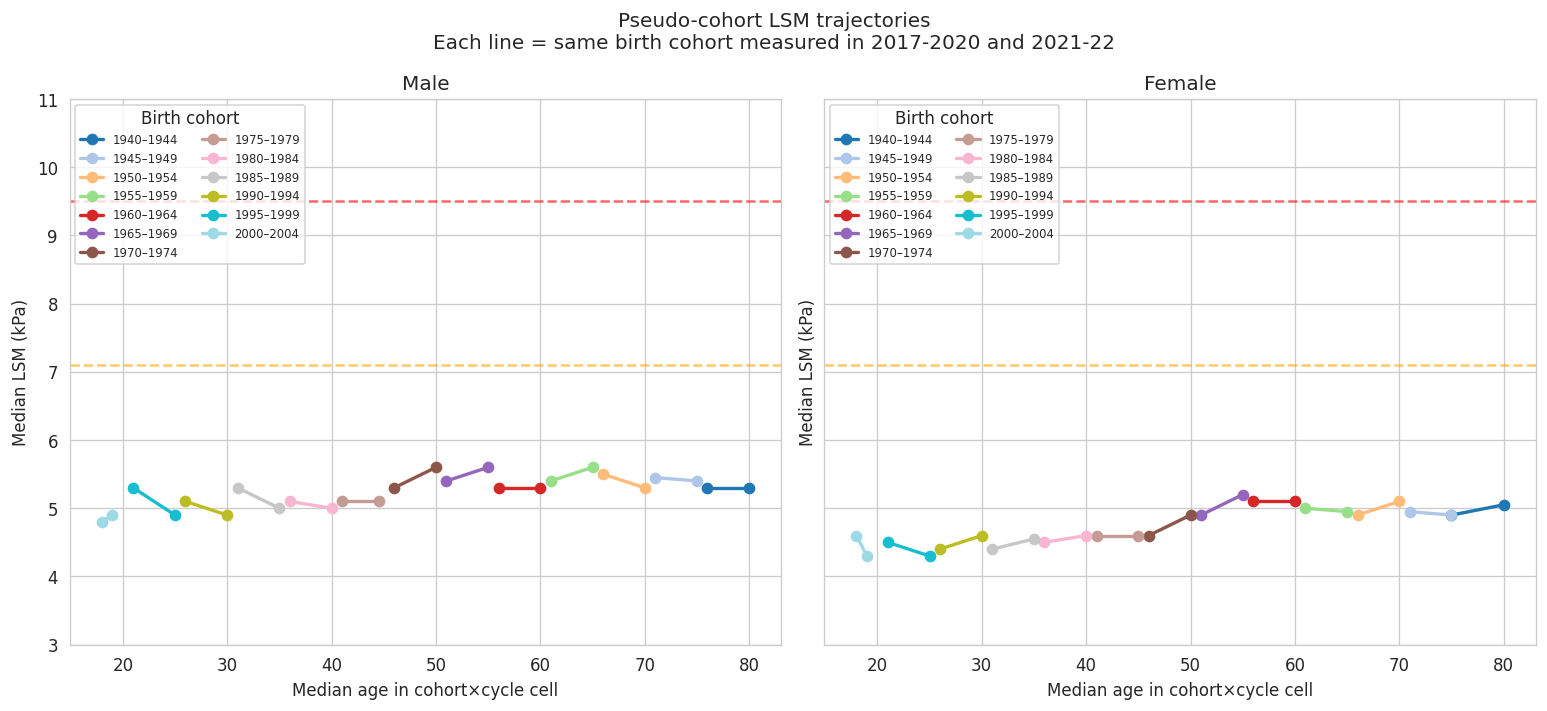

Mean annual LSM change by sex:


delta_lsm         annual_change        
            mean     std          mean     std
SEX                                           
Female    0.0615  0.1827       -0.0025  0.0966
Male     -0.0346  0.2055       -0.0029  0.0591

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
cmap = plt.cm.tab20

for ax, sex in zip(axes, ['Male', 'Female']):
    sub     = cohort_lsm[cohort_lsm['SEX'] == sex].sort_values(['BIRTH_COHORT', 'CYCLE'])
    cohorts = sorted(sub['BIRTH_COHORT'].unique())
    for i, bc in enumerate(cohorts):
        cdata = sub[sub['BIRTH_COHORT'] == bc].sort_values('CYCLE')
        ax.plot(cdata['age_median'], cdata['lsm_median'], 'o-',
                color=cmap(i / max(len(cohorts) - 1, 1)),
                label=f'{int(bc)}–{int(bc+4)}', markersize=6, lw=2)
    ax.axhline(LSM_F01, color='orange', ls='--', alpha=0.6)
    ax.axhline(LSM_F34, color='red',    ls='--', alpha=0.6)
    ax.set_xlabel('Median age in cohort×cycle cell')
    ax.set_ylabel('Median LSM (kPa)')
    ax.set_title(f'{sex}')
    ax.legend(title='Birth cohort', fontsize=7, ncol=2, loc='upper left')
    ax.set_ylim(3, 11)

plt.suptitle('Pseudo-cohort LSM trajectories\n'
             'Each line = same birth cohort measured in 2017-2020 and 2021-22', fontsize=12)
plt.tight_layout()
plt.show()

print('Mean annual LSM change by sex:')
display(piv.groupby('SEX')[['delta_lsm', 'annual_change']].agg(['mean', 'std']).round(4))

## 5. FIB-4 vs LSM concordance

FIB-4 correlates with LSM in NAFLD populations, but in a general population sample
the correlation is weak — especially in older age groups where age-related platelet
decline inflates FIB-4 independent of true fibrosis.

In [9]:
conc = lsm_cross[lsm_cross['FIB4'].notna()].copy()
conc['FIB4_CAT'] = pd.cut(conc['FIB4'],
    bins=[0, FIB4_LOW, FIB4_HIGH, np.inf],
    labels=['Low (<1.30)', 'Interm (1.30-2.67)', 'High (>2.67)'])

print(f'Subjects with FIB-4 and LSM: {len(conc):,}')
print('\nRow %: FIB-4 category → LSM category')
ct = pd.crosstab(conc['FIB4_CAT'], conc['LSM_CAT'], margins=True,
                 normalize='index').round(3) * 100
display(ct)

print('\nSpearman r(FIB-4, LSM) by age group:')
rows = []
for ag in AGE_LABELS:
    sub = conc[conc['AGE_GROUP'] == ag][['FIB4', 'LSM_KPA']].dropna()
    if len(sub) < 10:
        continue
    r, p = stats.spearmanr(sub['FIB4'], sub['LSM_KPA'])
    rows.append({'age_group': ag, 'n': len(sub), 'spearman_r': round(r, 3), 'p': round(p, 4)})
display(pd.DataFrame(rows))

Subjects with FIB-4 and LSM: 9,500

Row %: FIB-4 category → LSM category


LSM_CAT,Low F0-F1 (<7.1),Intermediate (7.1-9.4),High F3-F4 (≥9.5)
FIB4_CAT,,,
Low (<1.30),84.9,9.0,6.1
Interm (1.30-2.67),81.4,9.4,9.2
High (>2.67),59.4,13.2,27.4
All,82.7,9.3,8.0



Spearman r(FIB-4, LSM) by age group:


,age_group,n,spearman_r,p
0,30-39,904,0.070,0.0366
1,40-49,1830,-0.009,0.7137
2,50-59,2042,0.049,0.0262
3,60-69,2585,0.035,0.0714
4,70+,2139,0.053,0.0143


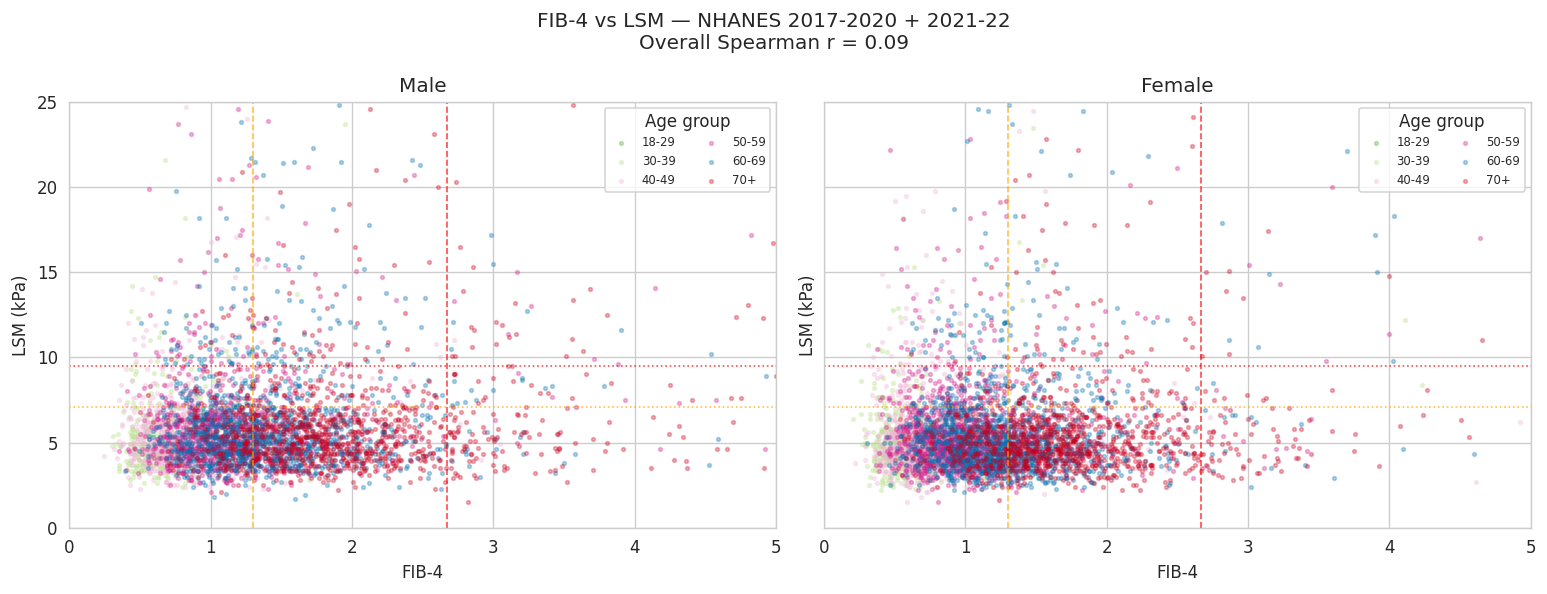

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
age_palette = dict(zip(AGE_LABELS,
    ['#4dac26', '#b8e186', '#f1b6da', '#d01c8b', '#0571b0', '#ca0020']))

for ax, sex in zip(axes, ['Male', 'Female']):
    for ag, color in age_palette.items():
        pts = conc[(conc['SEX'] == sex) & (conc['AGE_GROUP'] == ag)]
        ax.scatter(pts['FIB4'], pts['LSM_KPA'], s=5, alpha=0.3,
                   color=color, label=ag, rasterized=True)
    ax.axvline(FIB4_LOW,  color='orange', ls='--', lw=1, alpha=0.7)
    ax.axvline(FIB4_HIGH, color='red',    ls='--', lw=1, alpha=0.7)
    ax.axhline(LSM_F01,   color='orange', ls=':',  lw=1, alpha=0.7)
    ax.axhline(LSM_F34,   color='red',    ls=':',  lw=1, alpha=0.7)
    ax.set_xlim(0, 5); ax.set_ylim(0, 25)
    ax.set_xlabel('FIB-4'); ax.set_ylabel('LSM (kPa)')
    ax.set_title(f'{sex}')
    ax.legend(title='Age group', fontsize=7, ncol=2)

r_all, _ = stats.spearmanr(conc['FIB4'], conc['LSM_KPA'])
plt.suptitle(f'FIB-4 vs LSM — NHANES 2017-2020 + 2021-22\n'
             f'Overall Spearman r = {r_all:.2f}', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Steatosis (CAP) and fibrosis (LSM)

Steatosis severity (CAP) predicts faster fibrosis progression via NASH.
CAP thresholds: S0 <248, S1 248-267, S2 268-279, S3 ≥280 dB/m (Siddiqui 2018).

Steatosis categories:


STEATOSIS
S0 <11%      6136
S1 11-33%    1550
S2 34-66%     959
S3 >66%      5144
Name: count, dtype: int64

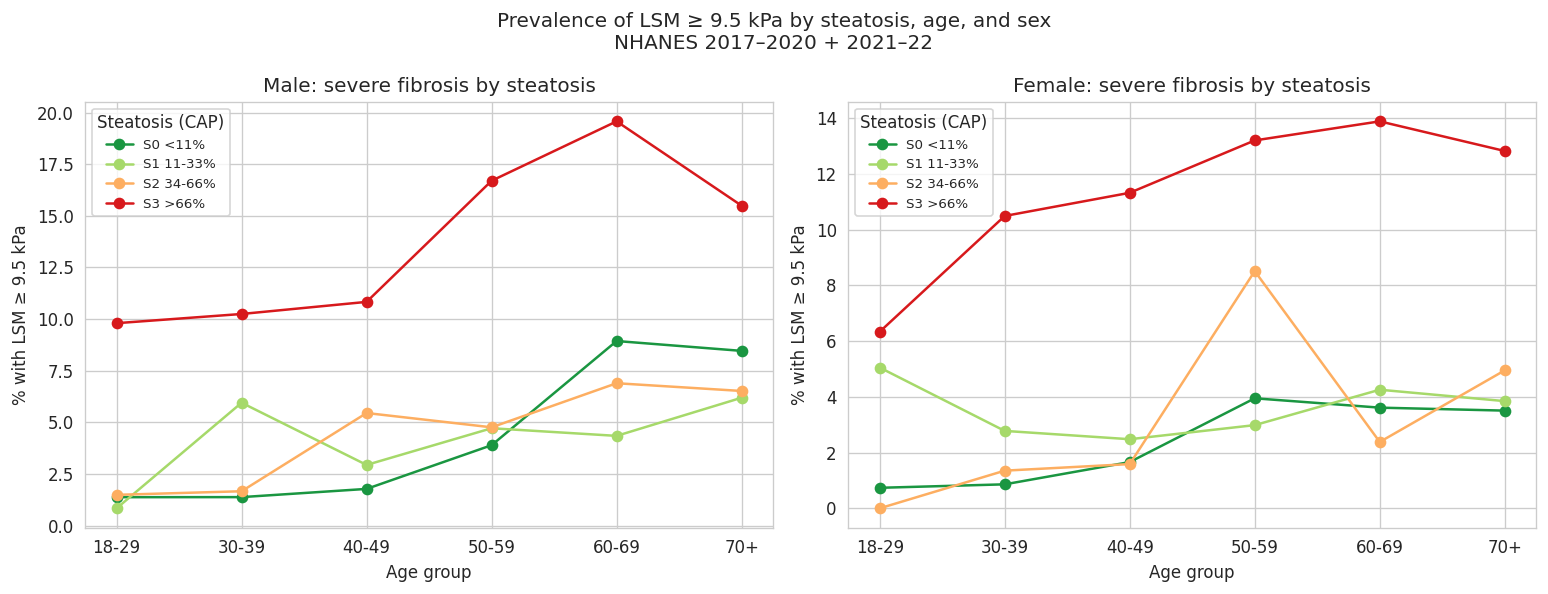

In [11]:
cap = lsm_cross[lsm_cross['CAP_DBM'].notna()].copy()
cap['STEATOSIS'] = pd.cut(cap['CAP_DBM'],
    bins=[0, 248, 268, 280, 500],
    labels=['S0 <11%', 'S1 11-33%', 'S2 34-66%', 'S3 >66%'])

print('Steatosis categories:')
display(cap['STEATOSIS'].value_counts().sort_index())

steat_order  = ['S0 <11%', 'S1 11-33%', 'S2 34-66%', 'S3 >66%']
steat_colors = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sex in zip(axes, ['Male', 'Female']):
    by_as = (cap[cap['SEX'] == sex]
             .groupby(['AGE_GROUP', 'STEATOSIS'])
             .apply(lambda g: (g['LSM_KPA'] >= LSM_F34).mean() * 100)
             .reset_index(name='pct_F34'))
    for sc, col in zip(steat_order, steat_colors):
        d = (by_as[by_as['STEATOSIS'] == sc]
             .set_index('AGE_GROUP').reindex(AGE_LABELS).reset_index())
        ax.plot(range(len(AGE_LABELS)), d['pct_F34'], 'o-', color=col, label=sc)
    ax.set_xticks(range(len(AGE_LABELS))); ax.set_xticklabels(AGE_LABELS)
    ax.set_xlabel('Age group'); ax.set_ylabel('% with LSM ≥ 9.5 kPa')
    ax.set_title(f'{sex}: severe fibrosis by steatosis')
    ax.legend(title='Steatosis (CAP)', fontsize=8)

plt.suptitle('Prevalence of LSM ≥ 9.5 kPa by steatosis, age, and sex\n'
             'NHANES 2017–2020 + 2021–22', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Summary tables for simulation

In [12]:
lsm_prev = lsm_cross.groupby(['AGE_GROUP', 'SEX']).apply(
    lambda g: pd.Series({
        'n':         len(g),
        'median_lsm': g['LSM_KPA'].median(),
        'pct_F01':   (g['LSM_KPA'] < LSM_F01).mean() * 100,
        'pct_interm': ((g['LSM_KPA'] >= LSM_F01) & (g['LSM_KPA'] < LSM_F34)).mean() * 100,
        'pct_F34':   (g['LSM_KPA'] >= LSM_F34).mean() * 100,
    })
).reset_index()

print('LSM prevalence by age and sex (2017-2020 + 2021-22):')
display(lsm_prev.round(1))

print('\nPseudo-cohort annual LSM change by sex:')
display(piv.groupby('SEX')[['delta_lsm', 'annual_change']].agg(['mean', 'std']).round(4))

lsm_prev.to_csv('outputs/lsm_prevalence_by_age_sex.csv', index=False)
piv.to_csv('outputs/lsm_pseudo_cohort_change.csv', index=False)
prev_race.to_csv('outputs/lsm_prevalence_by_age_sex_race.csv', index=False)
print('\nCSVs saved.')

LSM prevalence by age and sex (2017-2020 + 2021-22):


,AGE_GROUP,SEX,n,median_lsm,pct_F01,pct_interm,pct_F34
0,18-29,Female,1191.0,4.5,94.6,3.3,2.1
1,18-29,Male,1218.0,5.0,88.2,8.4,3.4
2,30-39,Female,1086.0,4.5,90.2,6.1,3.7
3,30-39,Male,939.0,5.1,86.9,7.9,5.2
4,40-49,Female,1037.0,4.6,86.6,8.2,5.2
5,40-49,Male,937.0,5.1,83.8,9.8,6.4
6,50-59,Female,1184.0,5.1,81.3,10.6,8.1
7,50-59,Male,1013.0,5.4,78.1,11.4,10.6
8,60-69,Female,1481.0,5.0,82.2,9.7,8.0
9,60-69,Male,1365.0,5.4,76.1,10.9,13.0



Pseudo-cohort annual LSM change by sex:


delta_lsm         annual_change        
            mean     std          mean     std
SEX                                           
Female    0.0615  0.1827       -0.0025  0.0966
Male     -0.0346  0.2055       -0.0029  0.0591


CSVs saved.


---
## 8. What EPIC Cosmos could add

**EPIC Cosmos** (~280 million de-identified EHR records, ~300 health systems, 2025) offers
what no open NHANES analysis can provide: **true individual-level longitudinal FIB-4 trajectories**.

### Specific analyses Cosmos enables that NHANES cannot

| Analysis | Why NHANES falls short | What Cosmos adds |
|----------|----------------------|------------------|
| True individual FIB-4 trajectories | One exam per person | Repeated AST/ALT/PLT across years → FIB-4 at each encounter |
| Age × sex × race × comorbidity-specific progression | Too few per cell | Millions of patients; rare subgroups tractable |
| Markov transition probabilities | No repeat measures | P(Low→Interm), P(Interm→High), P(regression) per year |
| Hard clinical endpoints | Mortality linkage limited to 2019 | ICD K74.x (cirrhosis), C22.0 (HCC), Z94.4 (transplant) |
| Secular trends by race | Only 3 LSM cycles total | Calendar-year trends 2010–2025 |

### Data elements to request

```
Demographics:    birth_year, sex, race/ethnicity
Labs (LOINCs):   AST 1920-8, ALT 1742-6, Platelets 777-3  — all encounters, with dates
Vitals:          BMI at each encounter
Diagnoses:       K70-K77 (liver disease), E11 (T2D), E66 (obesity), F10.x (alcohol use)
Outcomes:        K74.x (fibrosis/cirrhosis), C22.0 (HCC), Z94.4 (liver transplant)
```

### Recommended analysis plan

1. **Cohort:** adults ≥ 35 with ≥ 2 FIB-4-eligible lab encounters ≥ 1 year apart
2. **Derive FIB-4** at each encounter where AST, ALT, and PLT were drawn within 30 days
3. **Markov transition model:** states = Low / Intermediate / High / Cirrhosis / Death;  
   covariates = age at baseline, sex, race/ethnicity, BMI, DM, alcohol use disorder
4. **Validation:** apply the Cosmos-trained transition matrix to a simulated population
   initialised from NHANES FIB-4 distributions; confirm the simulation reproduces
   the observed NHANES cross-sectional FIB-4 age curves

### Limitations to anticipate

- **Selection bias:** care-seeking population — expect higher progression rates than
  NHANES population estimates
- **Lab standardisation:** AST/ALT assay methods vary by site and era
- **No LSM:** Cosmos has no FibroScan data; staging via FIB-4 or ICD codes only
- **Right-censoring:** patients may switch health systems